Example from OpenPNM documentation
https://openpnm.org/examples/tutorials/09_simulating_invasion.html

In [1]:
import openpnm as op
import numpy as np
import matplotlib.pyplot as plt
op.visualization.set_mpl_style()

In [2]:
# Create a demo regular network
np.random.seed(5)
pn = op.network.Demo(shape=[25, 25, 1], spacing=1e-4)

# Introduce air as a non-wetting phase
air = op.phase.Air(network=pn)
air['pore.contact_angle'] = 120
air['pore.surface_tension'] = 0.072
f = op.models.physics.capillary_pressure.washburn

# calculate entry pressures
air.add_model(propname='throat.entry_pressure',
              model=f, 
              surface_tension='throat.surface_tension',
              contact_angle='throat.contact_angle',
              diameter='throat.diameter')



   1. Identify all the throats that can be invaded at a given applied capillary pressure

   2. Use scipy.sparse.csgraph.connected_components to label each cluster

   3. Trim clusters that are not connected to the inlets


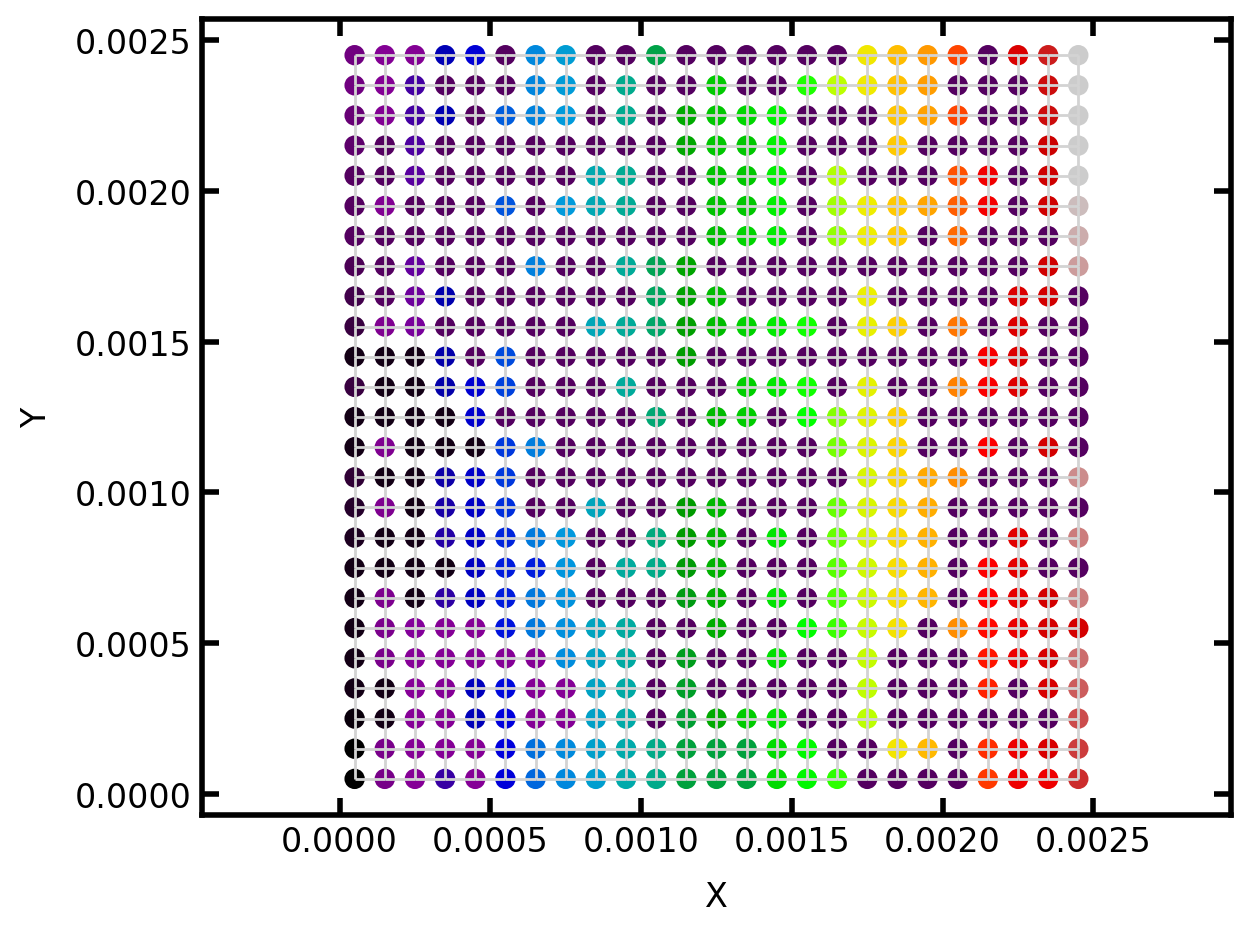

In [3]:
# helpful graph analysis tool from scipy
from scipy.sparse import csgraph as csg

# define entry pressure
Pc = air['throat.entry_pressure'].mean()
# find throats with sufficiently small 
Ts = 1.0*(air['throat.entry_pressure'] < 0.8*Pc)

am = pn.create_adjacency_matrix(weights=Ts, fmt='csr', triu=False, drop_zeros=True)
# clusters are connected components of air
clusters = csg.connected_components(am, directed=False)[1]

#Visualize result
ax = op.visualization.plot_coordinates(network=pn, color_by=clusters, s=40, cmap=plt.cm.nipy_spectral)
ax = op.visualization.plot_connections(network=pn, c='lightgrey', ax=ax);